In [1]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pd.set_option('display.max_rows', None)      # show every row
pd.set_option('display.max_columns', None)   # (optional) show every column

In [3]:
shots=pd.read_csv("shots_df.csv")
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,opponentTeam_id,opponentTeam_name,player_id,player_name,shot_isGoal,shot_xg,shot_xg2,possession_id,possession_duration,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,corner,counterattack,direct_free_kick,free_kick,free_kick_cross,set_piece_attack,throw_in,formation_back_3_or_5,formation_back_4,formation_narrow,formation_other,opponent_formation_back_3_or_5,opponent_formation_back_4,opponent_formation_narrow,opponent_formation_other,shot_distance,shot_angle,minute_exact,minute_int
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,Djurgården,8738,Rapid Wien,472359,H. Finndell,0,0.001169,0.034,2525775894,8.057077,6,5,87,100,2.525776e+09,5590087.0,1H,14.0,4.0,00:14:04.991,845.991078,2.525776e+09,pass,"['back_pass', 'short_or_medium_pass', 'shot_as...",81.0,63.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,546236.0,S. Haarala,RAMF,True,-144.0,NaN,9.0,472359.0,H. Finndell,LDMF,74.0,56.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,8.057077,"['attack', 'throw_in']",6.0,4.0,87.0,100.0,74.0,56.0,6713.0,Djurgården,4-2-3-1,True,False,False,right,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,38.013156,22.249024,14.083333,14
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,Djurgården,8738,Rapid Wien,546236,S. Haarala,0,0.369600,0.304,2525775957,31.259571,19,18,20,25,2.525776e+09,5590087.0,1H,16.0,18.0,00:16:18.835,979.835282,2.525776e+09,pass,"['deep_completion', 'forward_pass', 'key_pass'...",82.0,53.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,472359.0,H. Finndell,LDMF,True,0.0,NaN,8.0,546236.0,S. Haarala,RAMF,90.0,53.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,31.259571,['attack'],19.0,17.0,20.0,25.0,90.0,53.0,6713.0,Djurgården,4-2-3-1,True,True,False,center,0.3696,545637.0,N. Hedl,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,24.207437,28.131342,16.333333,16
2,2525775934,5590087,1H,17,22,00:17:22.682,1043.682911,88,50,8738,Rapid Wien,6713,Djurgården,66175,L. Schaub,0,0.019250,0.166,2525775914,

MERGING BOTH DATASETS

In [4]:
import json
import os

def extract_video_timestamps_from_shot_file(filepath):
    file_key = filepath.split("/")[-1].replace(".json", "")
    with open(filepath, 'r') as f:
        data = json.load(f)
    timestamps = [event['videoTimestamp'] for event in data if 'videoTimestamp' in event]
    return {file_key: timestamps}



In [5]:
df = extract_video_timestamps_from_shot_file("shot_pack/shots/644507.json")

In [6]:
def get_closest_tracking_frames_for_shots_with_context(shot_file, tracking_file, prev_frames=2, next_frames=2):
    """
    Extract closest tracking frames for shot timestamps, including previous and next frames around each match.
    
    Args:
        shot_file: Path to the shot JSON file
        tracking_file: Path to the tracking JSONL file
        prev_frames: Number of frames to include before the closest match (default: 2)
        next_frames: Number of frames to include after the closest match (default: 2)
    
    Returns:
        Dictionary with shot timestamps as keys and frame context data as values
    """
    with open(shot_file, 'r') as sf:
        shot_data = json.load(sf)
    
    video_timestamps = [
        str(event['videoTimestamp']) for event in shot_data 
        if 'videoTimestamp' in event and event.get('type', {}).get('primary') == 'shot'
    ]
    
    # First pass: read all tracking frames into memory
    tracking_frames = []
    with open(tracking_file, 'r') as tf:
        for line in tf:
            try:
                frame = json.loads(line)
                ts = frame.get('videoTimestamp') or frame.get('Videotimestamp')
                if ts is not None:
                    tracking_frames.append(frame)
            except json.JSONDecodeError:
                continue
    
    # Sort tracking frames by timestamp for easier context extraction
    tracking_frames.sort(key=lambda x: x.get('videoTimestamp') or x.get('Videotimestamp'))
    
    closest_frames_with_context = {}
    
    # Second pass: find closest matches and extract context
    for shot_ts in video_timestamps:
        shot_timestamp = float(shot_ts)
        min_diff = float('inf')
        closest_index = -1
        
        # Find the closest frame index
        for i, frame in enumerate(tracking_frames):
            frame_ts = frame.get('videoTimestamp') or frame.get('Videotimestamp')
            diff = abs(frame_ts - shot_timestamp)
            if diff < min_diff:
                min_diff = diff
                closest_index = i
        
        if closest_index != -1:
            # Extract previous frames (if available)
            prev_start_idx = max(0, closest_index - prev_frames)
            prev_frames_data = []
            for i in range(prev_start_idx, closest_index):
                frame_info = {
                    'frame': tracking_frames[i],
                    'position_relative_to_closest': i - closest_index,
                    'frame_type': 'previous'
                }
                prev_frames_data.append(frame_info)
            
            # Extract next frames (if available)  
            next_end_idx = min(len(tracking_frames), closest_index + next_frames + 1)
            next_frames_data = []
            for i in range(closest_index + 1, next_end_idx):
                frame_info = {
                    'frame': tracking_frames[i],
                    'position_relative_to_closest': i - closest_index,
                    'frame_type': 'next'
                }
                next_frames_data.append(frame_info)
            
            # Combine all frames for backward compatibility
            all_context_frames = prev_frames_data + [{
                'frame': tracking_frames[closest_index],
                'position_relative_to_closest': 0,
                'frame_type': 'closest',
                'is_closest': True
            }] + next_frames_data
            
            closest_frames_with_context[shot_ts] = {
                'closest_frame': tracking_frames[closest_index],
                'previous_frames': prev_frames_data,
                'next_frames': next_frames_data
            }
    
    return closest_frames_with_context

In [7]:
def get_all_shot_tracking_matches_with_context(shots_dir, tracking_dir, prev_frames=2, next_frames=2, max_files=10):
    """
    Process shot-tracking matches with context frames (limited to first max_files).
    
    Args:
        shots_dir: Directory containing shot JSON files
        tracking_dir: Directory containing tracking JSONL files
        prev_frames: Number of frames to include before each closest match (default: 2)
        next_frames: Number of frames to include after each closest match (default: 2)
        max_files: Maximum number of files to process (default: 10)
    
    Returns:
        Dictionary with match IDs as keys and frame context data as values
    """
    all_matches = {}
    processed_count = 0
    
    # Get sorted list of JSON files to ensure consistent ordering
    json_files = [f for f in os.listdir(shots_dir) if f.endswith('.json')]
    json_files.sort()  # Sort for consistent processing order
    
    for filename in json_files:
        if processed_count >= max_files:
            print(f"Reached maximum file limit ({max_files}). Stopping processing.")
            break
            
        match_id = filename.replace('.json', '')
        shot_path = os.path.join(shots_dir, f"{match_id}.json")
        tracking_path = os.path.join(tracking_dir, f"{match_id}_tracking_data.jsonl")
        
        if os.path.exists(tracking_path):
            result = get_closest_tracking_frames_for_shots_with_context(
                shot_path, tracking_path, prev_frames, next_frames
            )
            all_matches[match_id] = result
            processed_count += 1
            
            print(f"Processed {processed_count}/{max_files}: {match_id}")
        else:
            print(f"Tracking file missing for {match_id}")
    
    print(f"Total matches processed: {processed_count} out of {max_files} requested")
    return all_matches

In [8]:
all_data = get_all_shot_tracking_matches_with_context("shot_pack/shots", "shot_pack/jsonls",5,5,258)

Processed 1/258: 644494
Processed 2/258: 644507
Processed 3/258: 644510
Processed 4/258: 644513
Processed 5/258: 644524
Processed 6/258: 644543
Processed 7/258: 644545
Processed 8/258: 644546
Processed 9/258: 644547
Processed 10/258: 644548
Processed 11/258: 644549
Processed 12/258: 644550
Processed 13/258: 644551
Processed 14/258: 644552
Processed 15/258: 644553
Processed 16/258: 644554
Processed 17/258: 644555
Processed 18/258: 644556
Processed 19/258: 644557
Processed 20/258: 644559
Processed 21/258: 644560
Processed 22/258: 644561
Processed 23/258: 644562
Processed 24/258: 644563
Processed 25/258: 644564
Processed 26/258: 644565
Processed 27/258: 644566
Processed 28/258: 644567
Processed 29/258: 644570
Processed 30/258: 644572
Processed 31/258: 644573
Processed 32/258: 644574
Processed 33/258: 644575
Processed 34/258: 644576
Processed 35/258: 644578
Processed 36/258: 644580
Processed 37/258: 644581
Processed 38/258: 644583
Processed 39/258: 644584
Processed 40/258: 644585
Processed

In [9]:
def extract_match_data_from_directory(directory_path):
    """
    Create a dictionary where keys are match_ids and values are match_data
    from all JSON files in the specified directory.
    
    Args:
        directory_path (str): Path to the directory containing the JSON files
        
    Returns:
        dict: Dictionary with match_id as keys and match_data as values
    """
    match_data_dict = {}
    
    # Check if directory exists
    if not os.path.exists(directory_path):
        raise FileNotFoundError(f"Directory '{directory_path}' does not exist")
    
    # Iterate through all files in the directory
    for filename in os.listdir(directory_path):
        file_path = os.path.join(directory_path, filename)
        
        # Skip if it's not a file
        if not os.path.isfile(file_path):
            continue
            
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                # Read the first line which contains the match_data
                first_line = file.readline().strip()
                
                if first_line:
                    # Parse the JSON from the first line
                    data = json.loads(first_line)
                    
                    # Extract all the data (match_data, teams_data, players_data, FPS)
                    if 'match_data' in data:
                        match_id = data['match_data'].get('match_id')
                        
                        if match_id:
                            # Convert match_id to string to ensure consistency
                            match_id_str = str(match_id)
                            # Store the entire first line data (not just match_data)
                            match_data_dict[match_id_str] = data
                        else:
                            print(f"Warning: No match_id found in file '{filename}'")
                    else:
                        print(f"Warning: No match_data found in file '{filename}'")
                        
        except json.JSONDecodeError as e:
            print(f"Error parsing JSON in file '{filename}': {e}")
        except Exception as e:
            print(f"Error reading file '{filename}': {e}")
    
    return match_data_dict

In [10]:
match_info= extract_match_data_from_directory("shot_pack/jsonls")
match_info

{'644645': {'match_data': {'season_data': {'name': 'UCL 2024', 'id': 818378},
   'date': '2024-12-11',
   'match_id': 644645,
   'result': {'home': 0, 'away': 0}},
  'teams_data': {'home': {'name': 'SL Benfica', 'id': 61318},
   'away': {'name': 'Bologna', 'id': 12}},
  'players_data': {'61318': {'1262779': {'number': 1,
     'name': 'Anatolii Trubin',
     'position': 'GK'},
    '1267199': {'number': 3, 'name': 'Alvaro Fernandez', 'position': 'DL'},
    '1528624': {'number': 6, 'name': 'Alexander Bah', 'position': 'DR'},
    '122541': {'number': 30, 'name': 'Nicolas Otamendi', 'position': 'DC'},
    '1339424': {'number': 44, 'name': 'Tomas Araujo', 'position': 'DC'},
    '1156661': {'number': 8, 'name': 'Fredrik Aursnes', 'position': 'MC'},
    '1172508': {'number': 10, 'name': 'Orkun Kokcu', 'position': 'MC'},
    '1261490': {'number': 61, 'name': 'Florentino', 'position': 'DMC'},
    '80742': {'number': 11, 'name': 'Angel Di Maria', 'position': 'FWR'},
    '1158780': {'number': 14, 

In [11]:
# Initialize the new structure
all_data_augmented = {}

# Loop over each match in all_data
for match_id, timestamp_dict in all_data.items():
    all_data_augmented[match_id] = all_data[match_id]

    for timestamp, frame_group in timestamp_dict.items():
        all_data_augmented[match_id][timestamp]["match_info"]= match_info[match_id]



In [12]:
all_data_augmented["644494"]["182.042218"]["match_info"]

{'match_data': {'season_data': {'name': 'UCF 2024', 'id': 817384},
  'date': '2024-11-28',
  'match_id': '644494',
  'result': {'home': 0, 'away': 1}},
 'teams_data': {'home': {'name': 'The New Saints', 'id': 66365},
  'away': {'name': 'Djurgaarden', 'id': 61258}},
 'players_data': {'66365': {'1281528': {'number': 25,
    'name': 'Connor Roberts',
    'position': 'GK'},
   '1171150': {'number': 2, 'name': 'Josh Pask', 'position': 'DC'},
   '43827': {'number': 16, 'name': 'Harrison Mcgahey', 'position': 'DC'},
   '1541716': {'number': 22, 'name': 'Danny Davies', 'position': 'DL'},
   '1169867': {'number': 24, 'name': 'Ash Baker', 'position': 'DR'},
   '1162940': {'number': 10, 'name': 'Daniel Redmond', 'position': 'MC'},
   '1262330': {'number': 14, 'name': 'Daniel Williams', 'position': 'MC'},
   '1423089': {'number': 7, 'name': 'Joshua Daniels', 'position': 'FWR'},
   '1271100': {'number': 9, 'name': 'Declan Mcmanus', 'position': 'FW'},
   '1181037': {'number': 17, 'name': 'Jordan Wil

In [19]:
shots['videoTimestamp'] = shots['videoTimestamp'].astype(str)

In [20]:
# Build lookup: videoTimestamp → full frame info (includes match_info now)
timestamp_lookup = {}
for match in all_data_augmented.values():
    for timestamp, frame_info in match.items():
        timestamp_lookup[timestamp] = frame_info

# Extract frame parts
def extract_frame_part(row, part):
    frame_data = timestamp_lookup.get(row['videoTimestamp'], {})
    return frame_data.get(part)

# Assign all frame-related columns
shots['closest_frame'] = shots.apply(lambda row: extract_frame_part(row, 'closest_frame'), axis=1)
shots['previous_frames'] = shots.apply(lambda row: extract_frame_part(row, 'previous_frames'), axis=1)
shots['next_frames'] = shots.apply(lambda row: extract_frame_part(row, 'next_frames'), axis=1)

# Assign match_info from the frame-level "match_info" key
shots['match_info'] = shots['videoTimestamp'].map(lambda ts: timestamp_lookup.get(ts, {}).get('match_info'))


In [21]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import json

# Load the mapping once globally
with open('shot_pack/mappings/team_event_id_to_tracking_id.json', 'r') as f:
    team_mapping = json.load(f)

def plot_all_frames_for_shot(row):
    all_frames = []
    frame_types = []

    for prev_frame in row['previous_frames']:
        all_frames.append(prev_frame['frame'])
        frame_types.append(f"Previous ({prev_frame['position_relative_to_closest']:+d})")

    all_frames.append(row['closest_frame'])
    frame_types.append("CLOSEST (Shot)")

    for next_frame in row['next_frames']:
        all_frames.append(next_frame['frame'])
        frame_types.append(f"Next ({next_frame['position_relative_to_closest']:+d})")

    if not all_frames:
        print("No frames to plot.")
        return

    # Match info
    match_info = row['match_info']
    players_data = match_info['players_data']
    home_team_id = str(match_info['teams_data']['home']['id'])
    away_team_id = str(match_info['teams_data']['away']['id'])
    home_team = match_info['teams_data']['home']['name']
    away_team = match_info['teams_data']['away']['name']
    season = match_info['match_data']['season_data']['name']
    match_title = f"{home_team} vs {away_team} {season}"

    # Layout
    num_frames = len(all_frames)
    rows, cols = (1, num_frames) if num_frames <= 3 else (2, (num_frames + 1) // 2)
    figsize = (6 * cols, 6 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    fig.suptitle(match_title, fontsize=16, fontweight='bold', y=0.98)

    if num_frames == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes
    else:
        axes = axes.flatten()

    # Plot each frame
    for i, (frame, frame_type) in enumerate(zip(all_frames, frame_types)):
        ax = axes[i]
        team_ids = list(frame['data'].keys())
        if len(team_ids) != 2:
            ax.text(0.5, 0.5, f"Invalid frame data\n{frame_type}",
                    ha='center', va='center', transform=ax.transAxes)
            continue

        team0_id, team1_id = team_ids
        team0 = frame['data'][team0_id]
        team1 = frame['data'][team1_id]
        ball = frame.get('ball', None)

        pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                      pitch_color='grass', line_color='white')
        pitch.draw(ax=ax)

        def get_player_colors(team_players, team_id):
            colors = []
            for player in team_players:
                player_id = str(player['id'])
                if team_id in players_data and player_id in players_data[team_id]:
                    position = players_data[team_id][player_id]['position']
                    if position == 'GK':
                        colors.append('yellow')
                    else:
                        colors.append('blue' if team_id == home_team_id else 'red')
                else:
                    colors.append('blue' if team_id == home_team_id else 'red')
            return colors

        team0_colors = get_player_colors(team0, team0_id)
        team1_colors = get_player_colors(team1, team1_id)

        pitch.scatter([p['x'] for p in team0], [p['y'] for p in team0], ax=ax,
                      c=team0_colors, s=80, edgecolors='black', alpha=0.8)
        pitch.scatter([p['x'] for p in team1], [p['y'] for p in team1], ax=ax,
                      c=team1_colors, s=80, edgecolors='black', alpha=0.8)

        if ball and ball[0] is not None and ball[1] is not None:
            pitch.scatter(ball[0], ball[1], ax=ax, color='white', edgecolors='black', s=150)

        timestamp = frame.get('videoTimestamp') or frame.get('Videotimestamp')
        title_color = 'red' if 'CLOSEST' in frame_type else 'black'
        ax.set_title(f"{frame_type}\nTime: {timestamp:.2f}s" if timestamp else frame_type,
                     fontsize=12, fontweight='bold' if 'CLOSEST' in frame_type else 'normal',
                     color=title_color)

    for i in range(num_frames, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


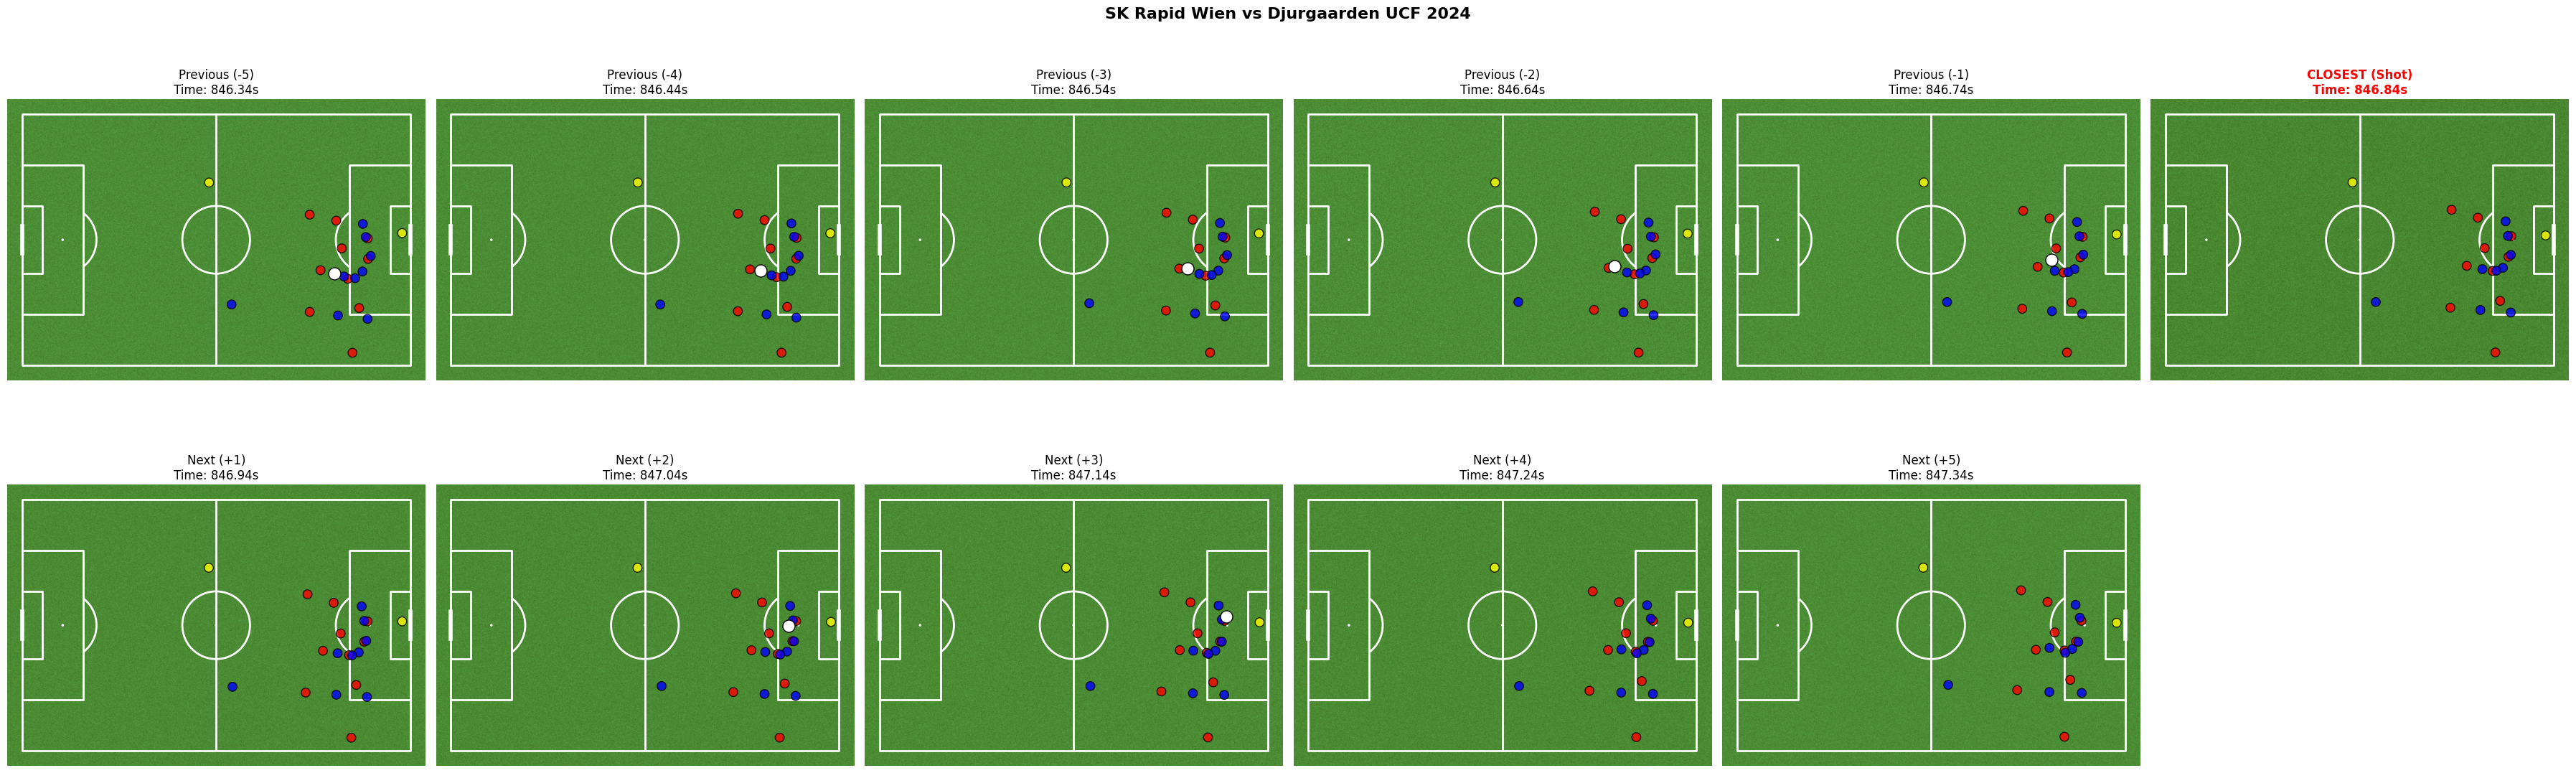

In [22]:

row = shots.iloc[0]
plot_all_frames_for_shot(row)


In [23]:
import json
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Load the mapping once
with open("shot_pack/mappings/player_event_id_to_tracking_id.json") as f:
    event_to_tracking_map = json.load(f)

def plot_closest_frame_for_shot(row):
    frame = row['closest_frame']
    match_info = row['match_info']
    players_data = match_info.get('players_data', {})

    home_team_id = str(match_info['teams_data']['home']['id'])
    away_team_id = str(match_info['teams_data']['away']['id'])
    home_team = match_info['teams_data']['home']['name']
    away_team = match_info['teams_data']['away']['name']
    season = match_info['match_data']['season_data']['name']
    match_title = f"{home_team} vs {away_team} ({season})"

    frame_data = frame['data']
    if len(frame_data) != 2:
        print("Invalid frame data (not 2 teams)")
        return
    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]
    ball = frame.get('ball')

    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                  pitch_color='grass', line_color='white')
    fig, ax = pitch.draw(figsize=(8, 6))
    fig.suptitle(match_title, fontsize=14, fontweight='bold')

    def get_colors(team_players, team_id):
        colors = []
        for p in team_players:
            pid = str(p['id'])
            if team_id in players_data and pid in players_data[team_id]:
                role = players_data[team_id][pid].get('position', '')
                if role == 'GK':
                    colors.append('green')
                else:
                    colors.append('blue' if team_id == home_team_id else 'red')
            else:
                colors.append('blue' if team_id == home_team_id else 'red')
        return colors

    # Plot team players
    pitch.scatter([p['x'] for p in team0], [p['y'] for p in team0], ax=ax,
                  c=get_colors(team0, team0_id), s=80, edgecolors='black', alpha=0.8)
    pitch.scatter([p['x'] for p in team1], [p['y'] for p in team1], ax=ax,
                  c=get_colors(team1, team1_id), s=80, edgecolors='black', alpha=0.8)

    # Ball
    if isinstance(ball, (list, tuple)) and len(ball) >= 2 and None not in ball:
        pitch.scatter(ball[0], ball[1], ax=ax, color='white', edgecolors='black', s=150, zorder=5)

    # Shooter: use tracking position based on mapped ID
    shooter_event_id = str(row['player_id'])
    tracking_id = str(event_to_tracking_map.get(shooter_event_id))
    shooter_coords = None

    if tracking_id and tracking_id != 'None':
        for team in [team0, team1]:
            for player in team:
                if str(player['id']) == tracking_id:
                    shooter_coords = (player['x'], player['y'])
                    pitch.scatter(player['x'], player['y'], ax=ax,
                                  color='black', s=120, edgecolors='white', zorder=6, label='Shooter')
                    break
            if shooter_coords:
                break

    # Arrow from shooter's tracked position to goal center
    if shooter_coords:
        pitch.annotate('', xy=(0, 34), xytext=shooter_coords,
                       arrowprops=dict(arrowstyle='->', color='black', lw=2), ax=ax)

    # Timestamp
    timestamp = frame.get('Videotimestamp', None)
    time_str = f"{timestamp:.2f}s" if timestamp else "Unknown Time"
    ax.set_title(f"Shot Frame • {time_str}", fontsize=12, color='darkred')

    plt.tight_layout()
    plt.show()


In [24]:
import json
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Load the mapping once
with open("shot_pack/mappings/player_event_id_to_tracking_id.json") as f:
    event_to_tracking_map = json.load(f)

def plot_closest_frame_for_shot(row):
    frame = row['closest_frame']
    match_info = row['match_info']
    players_data = match_info.get('players_data', {})

    home_team_id = str(match_info['teams_data']['home']['id'])
    away_team_id = str(match_info['teams_data']['away']['id'])
    home_team = match_info['teams_data']['home']['name']
    away_team = match_info['teams_data']['away']['name']
    season = match_info['match_data']['season_data']['name']
    match_title = f"{home_team} vs {away_team} ({season})"

    frame_data = frame['data']
    if len(frame_data) != 2:
        print("Invalid frame data (not 2 teams)")
        return
    team0_id, team1_id = frame_data.keys()
    team0 = frame_data[team0_id]
    team1 = frame_data[team1_id]
    ball = frame.get('ball')

    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                  pitch_color='grass', line_color='white')
    fig, ax = pitch.draw(figsize=(8, 6))
    fig.suptitle(match_title, fontsize=14, fontweight='bold')

    def get_colors(team_players, team_id):
        colors = []
        for p in team_players:
            pid = str(p['id'])
            if team_id in players_data and pid in players_data[team_id]:
                role = players_data[team_id][pid].get('position', '')
                if role == 'GK':
                    colors.append('green')
                else:
                    colors.append('blue' if team_id == home_team_id else 'red')
            else:
                colors.append('blue' if team_id == home_team_id else 'red')
        return colors

    pitch.scatter([p['x'] for p in team0], [p['y'] for p in team0], ax=ax,
                  c=get_colors(team0, team0_id), s=80, edgecolors='black', alpha=0.8)
    pitch.scatter([p['x'] for p in team1], [p['y'] for p in team1], ax=ax,
                  c=get_colors(team1, team1_id), s=80, edgecolors='black', alpha=0.8)

    if isinstance(ball, (list, tuple)) and len(ball) >= 2 and None not in ball:
        pitch.scatter(ball[0], ball[1], ax=ax, color='white', edgecolors='black', s=150, zorder=5)

    shooter_event_id = str(row['player_id'])
    tracking_id = str(event_to_tracking_map.get(shooter_event_id))
    shooter_coords = None

    if tracking_id and tracking_id != 'None':
        for team in [team0, team1]:
            for player in team:
                if str(player['id']) == tracking_id:
                    shooter_coords = (player['x'], player['y'])
                    pitch.scatter(player['x'], player['y'], ax=ax,
                                  color='black', s=120, edgecolors='white', zorder=6, label='Shooter')
                    break
            if shooter_coords:
                break

    # Determine goal direction and draw arrow
    if shooter_coords:
        shooter_team_id = str(row['team_id'])
        shooter_team = team0 if team0_id == shooter_team_id else team1

        # Try to find GK in shooter's team
        gk_coords = None
        for p in shooter_team:
            pid = str(p['id'])
            if pid in players_data.get(shooter_team_id, {}) and players_data[shooter_team_id][pid].get('position') == 'GK':
                gk_coords = (p['x'], p['y'])
                break

        # If GK is available → compare positions
        if gk_coords:
            attack_right = shooter_coords[0] > gk_coords[0]
        else:
            # No GK found → use fallback: closest goal
            attack_right = shooter_coords[0] > 52.5

        goal_x = 105 if attack_right else 0
        goal_y = 34

        pitch.annotate('', xy=(goal_x, goal_y), xytext=shooter_coords,
                       arrowprops=dict(arrowstyle='->', color='black', lw=2), ax=ax)

    timestamp = frame.get('Videotimestamp', None)
    time_str = f"{timestamp:.2f}s" if timestamp else "Unknown Time"
    ax.set_title(f"Shot Frame • {time_str}", fontsize=12, color='darkred')

    plt.tight_layout()
    plt.show()


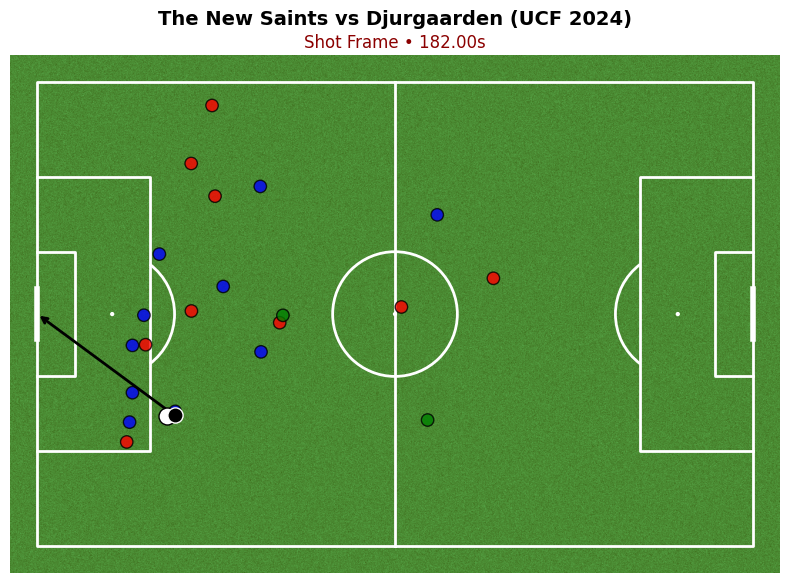

In [25]:
plot_closest_frame_for_shot(shots[(shots["matchId"]==5590005)].iloc[0])

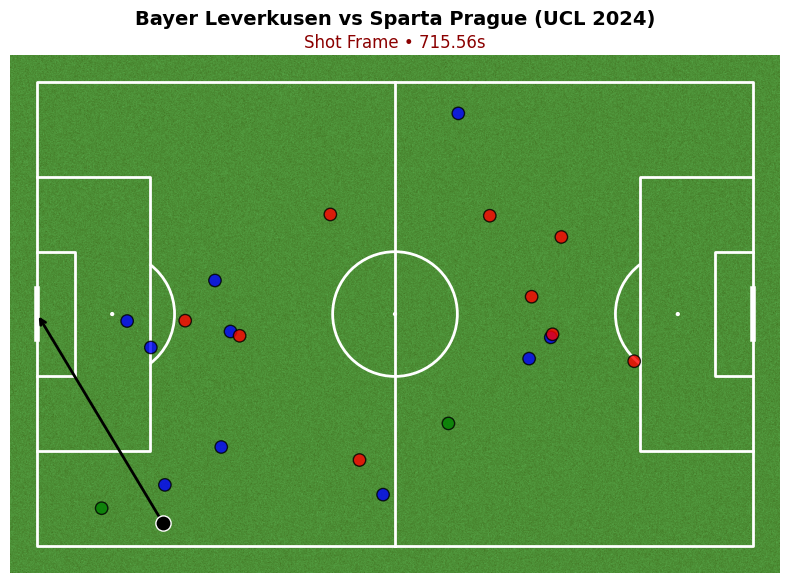

In [26]:
plot_closest_frame_for_shot(shots.loc[800])

In [27]:
shots[(shots["matchId"]==5590005)].iloc[0]["closest_frame"]

{'data': {'61258': [{'x': 35.58, 'y': 32.73, 'vis': False, 'id': 1154690},
   {'x': 15.9, 'y': 29.5, 'vis': True, 'id': 1161107},
   {'x': 25.65, 'y': 64.61, 'vis': False, 'id': 1157026},
   {'x': 57.28, 'y': 18.45, 'vis': False, 'id': 1157164},
   {'x': 22.59, 'y': 56.1, 'vis': False, 'id': 1170223},
   {'x': 66.94, 'y': 39.25, 'vis': False, 'id': 1157169},
   {'x': 13.13, 'y': 15.23, 'vis': True, 'id': 1978058},
   {'x': 20.16, 'y': 19.12, 'vis': True, 'id': 1156833},
   {'x': 26.09, 'y': 51.3, 'vis': False, 'id': 1330158},
   {'x': 53.44, 'y': 35.04, 'vis': False, 'id': 1157107},
   {'x': 22.62, 'y': 34.45, 'vis': True, 'id': 1299319}],
  '66365': [{'x': 32.84, 'y': 28.45, 'vis': True, 'id': 1281415},
   {'x': 15.65, 'y': 33.83, 'vis': True, 'id': 43827},
   {'x': 58.7, 'y': 48.56, 'vis': False, 'id': 1271100},
   {'x': 27.29, 'y': 38.05, 'vis': False, 'id': 1162940},
   {'x': 13.97, 'y': 22.46, 'vis': True, 'id': 1169867},
   {'x': 13.97, 'y': 29.4, 'vis': True, 'id': 1171150},
   

In [28]:
shots[(shots["matchId"]==5590005)].iloc[0]

id                                                                                     2383052716
matchId                                                                                   5590005
matchPeriod                                                                                    1H
minute                                                                                          3
second                                                                                          1
matchTimestamp                                                                       00:03:01.042
videoTimestamp                                                                         182.042218
location_x                                                                                     80
location_y                                                                                     30
team_id                                                                                      6713
team_name           

In [29]:
shots.loc[27,"closest_frame"]["ball"]

[7.85, 38.43]

In [30]:
shots.loc[27,:]

id                                                                                     2456216425
matchId                                                                                   5589317
matchPeriod                                                                                    1H
minute                                                                                          4
second                                                                                          3
matchTimestamp                                                                       00:04:03.051
videoTimestamp                                                                         244.051591
location_x                                                                                     92
location_y                                                                                     57
team_id                                                                                       687
team_name           

In [31]:
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,opponentTeam_id,opponentTeam_name,player_id,player_name,shot_isGoal,shot_xg,shot_xg2,possession_id,possession_duration,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,corner,counterattack,direct_free_kick,free_kick,free_kick_cross,set_piece_attack,throw_in,formation_back_3_or_5,formation_back_4,formation_narrow,formation_other,opponent_formation_back_3_or_5,opponent_formation_back_4,opponent_formation_narrow,opponent_formation_other,shot_distance,shot_angle,minute_exact,minute_int,closest_frame,previous_frames,next_frames,match_info
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,Djurgården,8738,Rapid Wien,472359,H. Finndell,0,0.001169,0.034,2525775894,8.057077,6,5,87,100,2.525776e+09,5590087.0,1H,14.0,4.0,00:14:04.991,845.991078,2.525776e+09,pass,"['back_pass', 'short_or_medium_pass', 'shot_as...",81.0,63.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,546236.0,S. Haarala,RAMF,True,-144.0,NaN,9.0,472359.0,H. Finndell,LDMF,74.0,56.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,8.057077,"['attack', 'throw_in']",6.0,4.0,87.0,100.0,74.0,56.0,6713.0,Djurgården,4-2-3-1,True,False,False,right,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,38.013156,22.249024,14.083333,14,"{'data': {'61258': [{'x': 81.4, 'y': 26.97, 'v...","[{'frame': {'data': {'61258': [{'x': 80.72, 'y...","[{'frame': {'data': {'61258': [{'x': 81.36, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,Djurgården,8738,Rapid Wien,546236,S. Haarala,0,0.369600,0.304,2525775957,31.259571,19,18,20,25,2.525776e+09,5590087.0,1H,16.0,18.0,00:16:18.835,979.835282,2.525776e+09,pass,"['deep_completion', 'forward_pass', 'key_pass'...",82.0,53.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,472359.0,H. Finndell,LDMF,True,0.0,NaN,8.0,546236.0,S. Haarala,RAMF,90.0,53.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,31.259571,['attack'],19.0,17.0,20.0,25.0,90.0,53.0,6713.0,Djurgården,4-2-3-1,True,True,False,center,0.3

In [32]:
shots.loc[27,"match_info"]

{'match_data': {'season_data': {'name': 'UEL 2024', 'id': 818379},
  'date': '2025-02-20',
  'match_id': 662723,
  'result': {'home': 5, 'away': 2}},
 'teams_data': {'home': {'name': 'Real Sociedad', 'id': 4273},
  'away': {'name': 'FC Midtjylland', 'id': 61326}},
 'players_data': {'4273': {'200058': {'number': 1,
    'name': 'Alex Remiro',
    'position': 'GK'},
   '1252773': {'number': 3, 'name': 'Aihen Munoz', 'position': 'DL'},
   '279953': {'number': 5, 'name': 'Igor Zubeldia', 'position': 'DC'},
   '193811': {'number': 6, 'name': 'Aritz Elustondo', 'position': 'DR'},
   '1217645': {'number': 21, 'name': 'Nayef Aguerd', 'position': 'DC'},
   '1309136': {'number': 16,
    'name': 'Jon Ander Olasagasti',
    'position': 'DMC'},
   '1166785': {'number': 23, 'name': 'Brais Mendez', 'position': 'MC'},
   '1290406': {'number': 24, 'name': 'Luka Sucic', 'position': 'MC'},
   '1254156': {'number': 7, 'name': 'Ander Barrenetxea', 'position': 'FWL'},
   '273054': {'number': 10, 'name': 'Mik